# START HERE — the trench pull from a bending-plate model
Companion notebook to *The 'trench pull' force: constraints from elasto-plastic bending models* (Sandiford, JGR: Solid Earth).
Run it from the repository root in the `ferrite-figs` environment (`README.md` §2).

It does the paper's analysis on the included model output, in order:
1. load a model and its topography;
2. find the columns the force is defined between (trench, first isostatic; also max-moment, forebulge);
3. the Cauchy stresses through those columns;
4. the trench pull ΔGPE\* and the equilibrium identity ΔN_D = ΔGPE\*;
5. the equivalent density ρ̂ and the effective arm;
6. the pull reconstructed from ρ̂;
7. the corrected density ρ\*;
8. the same numbers for every model in `data/` (all suites);
9. the paper's figures from their scripts.

Sign convention, stated once: tension positive, as in the paper. The plate is massless, so all stresses are perturbations from a
uniform lithostat; vertical stress is therefore shown as the paper shows it — as a pressure anomaly relative to the isostatic
column, Δ(−σzz), in which a pressure deficit is negative.

In [1]:
import os, sys, glob, subprocess
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
assert os.path.isdir("analysis") and os.path.isdir("data"), "run this notebook from the repository root"
sys.path[:0] = ["analysis", "figures"]
from gpe_analysis import Model, trench_ref_km, reference_lines, deformed_shear_gradient, trench_pull
G = 9.81; RHO_M, RHO_W = 3300.0, 1000.0; DRHO_G = (RHO_M - RHO_W) * G     # mantle and water density; foundation Δρ·g

## 1. Load the reference model
Uniform Tresca plate, σY = 150 MPa, h = 60 km, trench load V = 4 TN/m. Each model directory holds `gpe_model.vtu` (the
finite-element fields: displacement and stress) and `gpe_topo.csv`. The exported `sigma_*` are the solver's second
Piola–Kirchhoff stress on the reference mesh; `cauchy_fields()` converts them to Cauchy stress (σ = J⁻¹ F S Fᵀ) and
`deformed_line(x)` samples that on a vertical line through the deformed plate. Every stress below comes through those two calls.

mesh Nx x Nz = 801 x 49;  plate thickness h = 60 km
check: Python Cauchy τzx vs the solver's own exported Cauchy τzx — max difference 0.008 MPa


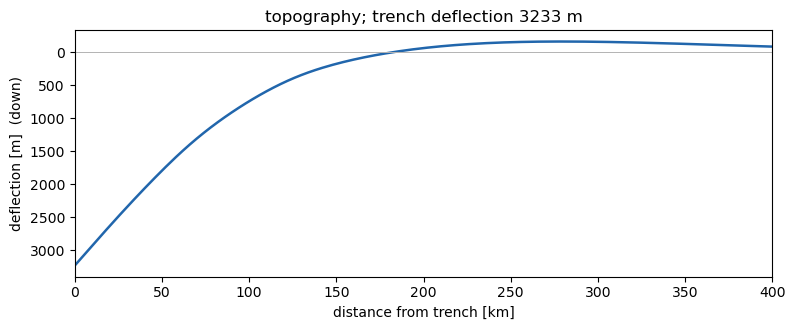

In [2]:
MODEL = "data/suite1_strength/tresca_deep_150_60km_V4"
m = Model(MODEL)
print(f"mesh Nx x Nz = {m.Nx} x {m.Nz};  plate thickness h = {m.H/1e3:.0f} km")
Cxx, Czz, Cxz = m.cauchy_fields()                                   # Cauchy stress, each (Nx, Nz)
print(f"check: Python Cauchy τzx vs the solver's own exported Cauchy τzx — max difference {np.nanmax(np.abs(Cxz - m.array('sigma_xz_cauchy [Pa]')))/1e6:.3f} MPa")
w = m.topography()                                                  # deflection of the plate top [m], positive down
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(m.xkm, w, color="#2166ac", lw=1.8); ax.axhline(0, color="0.7", lw=0.7)
ax.invert_yaxis(); ax.set_xlim(0, 400); ax.set_xlabel("distance from trench [km]"); ax.set_ylabel("deflection [m]  (down)")
ax.set_title(f"topography; trench deflection {w.max():.0f} m"); plt.show()

**Reference and deformed configurations — what the file holds and what is computed.** The solver is total-Lagrangian: it works entirely on the *undeformed* reference mesh and never moves it. So `gpe_model.vtu` holds (i) the reference node coordinates — a perfect rectangle, 1600 km × h — and (ii) the displacement `u` as point data. **The deformed coordinates are not in the file**: every plot below on the bent plate forms them as reference + u (ParaView's *Warp By Vector* on `u` does the same).

The stress in the file, `sigma_xx/zz/xz`, is the **second Piola–Kirchhoff stress S** — the stress that does work against the Green–Lagrange strain E = ½(FᵀF − I) — a *material* stress, expressed in axes that ride with the material and unchanged by a rigid rotation. That is what makes it convenient for the solver and wrong to read as a physical stress in a tilted plate. The **Cauchy stress** σ is the true stress in the fixed lab axes on the deformed body — what "vertical normal stress on a vertical line" means. `cauchy_fields()` performs the push-forward σ = J⁻¹ F S Fᵀ with F = I + ∂u/∂X: F on both sides carries the tensor from material to lab axes, J = det F converts per-reference-area to per-current-area. Strains here are ~0.2 %, so J ≈ 1 and the push-forward is in effect a rotation of the stress by the local plate tilt — which is why S and σ differ by a few percent of the field, most where the plate is steepest. (The solver also exports its own Cauchy shear, `sigma_xz_cauchy`; the check above shows the Python push-forward reproduces it to 0.01 MPa.)

## 2. Find the columns
The pull is defined between two vertical columns (manuscript Eq. 1, Fig. 1):
- the **trench column** x_T — the leftmost complete vertical line inside the deformed plate (the loaded face tilts, so it is not exactly x = 0);
- the **first isostatic column** x_I — the first place outboard where the deflection returns to zero (w = 0: no foundation load).

`reference_lines` also returns the **maximum-moment column** x_M (first V = ∫τzx dz = 0) and the forebulge.

trench x_T = 0.9 km;  first isostatic x_I = 182 km;  max-moment x_M = 89 km;  forebulge = 278 km


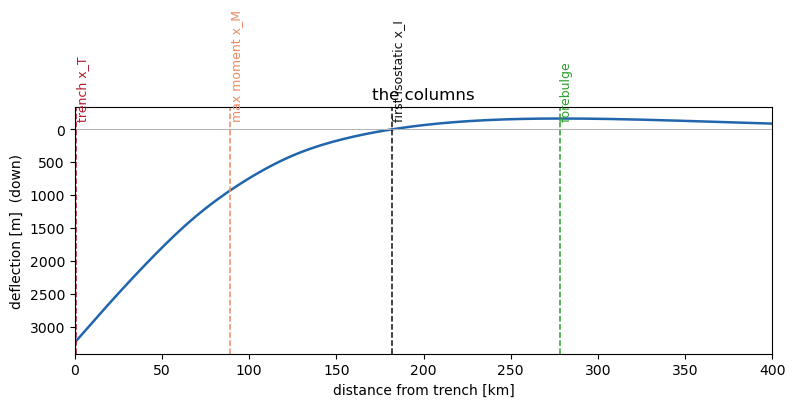

In [3]:
xt = trench_ref_km(m)
rl = reference_lines(m); xI, xM, xF = rl["isostatic"], rl["moment_max"], rl["outer_rise"]
print(f"trench x_T = {xt:.1f} km;  first isostatic x_I = {xI:.0f} km;  max-moment x_M = {xM:.0f} km;  forebulge = {xF:.0f} km")
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(m.xkm, w, color="#2166ac", lw=1.8); ax.axhline(0, color="0.7", lw=0.7)
for x, c, lab in [(xt, "#b2182b", "trench x_T"), (xM, "#ef8a62", "max moment x_M"), (xI, "#111111", "first isostatic x_I"), (xF, "#2ca02c", "forebulge")]:
    ax.axvline(x, color=c, lw=1.1, ls="--"); ax.text(x, 0, "  " + lab, color=c, fontsize=9, rotation=90, va="bottom")
ax.invert_yaxis(); ax.set_xlim(0, 400); ax.set_xlabel("distance from trench [km]"); ax.set_ylabel("deflection [m]  (down)"); ax.set_title("the columns"); plt.show()

## 3. Stresses through the plate and through the columns
First one field over the whole plate, drawn on the **deformed** mesh with the topography above it — `plot_field(m, name)` with
`name` one of `diff` (σxx − σzz), `sxz` (τzx), `szz` (the perturbation σzz), `rho` (the equivalent density ρ̂). The yield front
and the columns of section 2 are marked. Then three fields on the trench and max-moment columns, relative to the isostatic
column: the pressure anomaly Δ(−σzz) (the quantity of Fig. 2(b); deficit negative), τzx and σxx − σzz. Column depths are measured
from the undeflected surface so the columns are compared at the same absolute depth; the dotted line is each column's plate top.

In [ ]:
def plot_field(m, name="diff", window_km=300):
    """One Cauchy field on the deformed plate (pcolormesh on the deformed node positions), topography above,
    yield front and the reference columns marked.  Not to scale: the vertical exaggeration is computed and stated."""
    Cxx, Czz, Cxz = m.cauchy_fields()
    fld, lab, cmap = {"diff": (Cxx - Czz, "σxx − σzz  [MPa]", "RdBu_r"), "sxz": (Cxz, "τzx  [MPa]", "PuOr_r"),
                      "szz": (Czz, "σzz (perturbation)  [MPa]", "RdBu_r"), "sxx": (Cxx, "σxx (perturbation)  [MPa]", "RdBu_r"),
                      "rho": (m.array("dsxz_dx [Pa/m]") / G * 1e6, "equivalent density ρ̂  [kg/m³]", "PuOr_r")}[name]
    X = (m.x[:, None] + m.array("u", 0)) / 1e3; Z = (m.z[None, :] + m.array("u", 1)) / 1e3      # deformed node positions [km]
    win = X[:, 0] <= window_km; v = np.nanpercentile(np.abs(fld[win]), 99) / 1e6
    r = reference_lines(m); marks = [(trench_ref_km(m), "#b2182b", "x_T"), (r["moment_max"], "#ef8a62", "x_M"), (r["isostatic"], "k", "x_I")]
    fig, (a0, a1) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True, gridspec_kw={"height_ratios": [1, 3.2]}, constrained_layout=True)
    a0.plot(X[:, 0], Z[:, 0], color="#2166ac", lw=1.6); a0.axhline(0, color="0.7", lw=0.7); a0.set_ylabel("deflection [km]"); a0.invert_yaxis()
    pc = a1.pcolormesh(X, Z, fld / 1e6, cmap=cmap, vmin=-v, vmax=v, shading="gouraud"); fig.colorbar(pc, ax=a1, label=lab, pad=0.01)
    yld = m.array("yielded")
    if yld.max() > 0.5: a1.contour(X, Z, yld, levels=[0.5], colors="k", linewidths=0.8)             # yield front
    for x, c, t in marks:
        for a in (a0, a1): a.axvline(x, color=c, lw=1.0, ls="--")
        a1.text(x, Z.max() + 1, f" {t}", color=c, fontsize=9, va="top")
    a1.set_ylim(Z.max() + 8, Z.min() - 2); a1.set_xlim(0, window_km)
    a1.set_xlabel("distance from trench [km]"); a1.set_ylabel("depth [km]")
    fig.canvas.draw(); b = a1.get_position(); W, H = fig.get_size_inches()                       # actual vertical exaggeration of the drawn panel
    vex = (b.height * H / (Z.max() + 8 - Z.min() + 2)) / (b.width * W / window_km)
    a1.set_title(f"{lab.split('  ')[0]} on the deformed plate — vertical exaggeration ×{vex:.0f}; black line = yield front", fontsize=10)
    plt.show()

plot_field(m, "diff")
plot_field(m, "sxz")

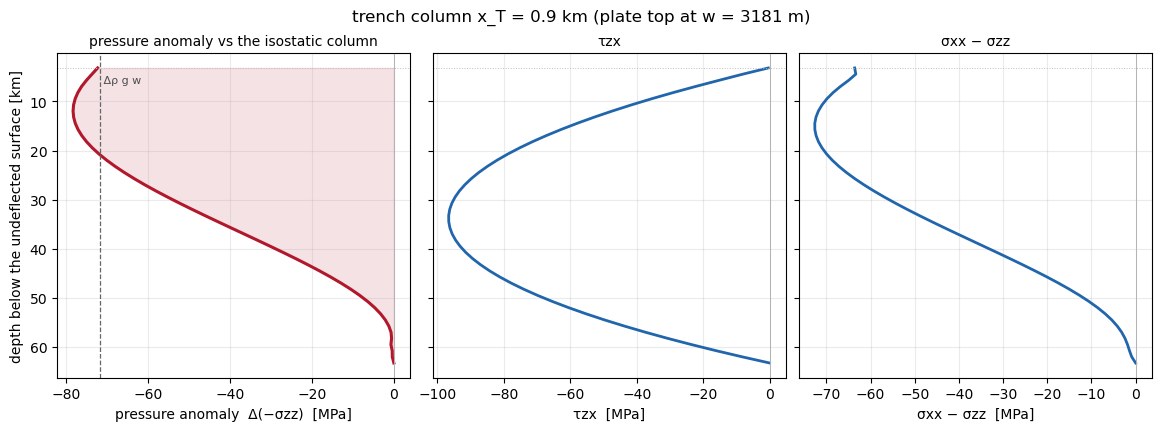

trench column x_T = 0.9 km: anomaly at the plate top  -72.3 MPa (Δρ g w = 71.8);  at the base -0.01 MPa;  ∫Δ(−σzz) dz = -2.542 TN/m;  V = ∫τzx dz = -3.878 TN/m


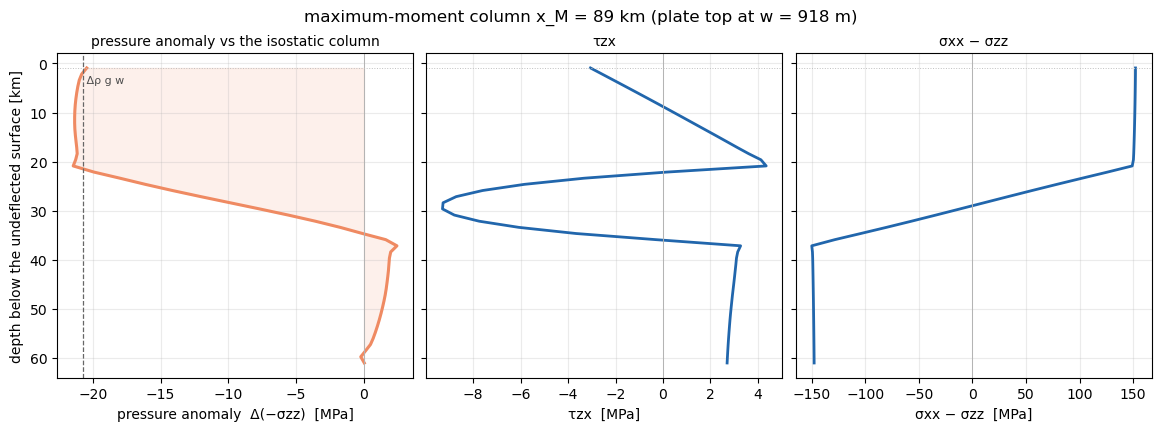

maximum-moment column x_M = 89 km: anomaly at the plate top  -20.5 MPa (Δρ g w = 20.7);  at the base  0.03 MPa;  ∫Δ(−σzz) dz = -0.539 TN/m;  V = ∫τzx dz = +0.002 TN/m


In [4]:
Lt, Li, Lm = m.deformed_line(xt), m.deformed_line(xI), m.deformed_line(xM)       # Cauchy stress on vertical lines through the deformed plate
def column_plot(L, name, col):
    z = L["z"]; wtop = z[0]
    dP = -(L["szz"] - np.interp(z, Li["z"], Li["szz"], right=0.0))                 # Δ(−σzz) relative to the isostatic column, same depths
    fig, ax = plt.subplots(1, 3, figsize=(11.5, 4.2), sharey=True, constrained_layout=True)
    ax[0].plot(dP / 1e6, z / 1e3, lw=2.2, color=col); ax[0].fill_betweenx(z / 1e3, dP / 1e6, 0, color=col, alpha=0.12)
    ax[0].axvline(-DRHO_G * wtop / 1e6, color="0.4", lw=0.9, ls="--"); ax[0].text(-DRHO_G * wtop / 1e6, wtop / 1e3 + 1.5, " Δρ g w", fontsize=8, color="0.3", va="top")
    ax[0].set_xlabel("pressure anomaly  Δ(−σzz)  [MPa]"); ax[0].set_title("pressure anomaly vs the isostatic column", fontsize=10)
    for a, key, lab in [(ax[1], "sxz", "τzx  [MPa]"), (ax[2], "n_d", "σxx − σzz  [MPa]")]:
        a.plot(L[key] / 1e6, z / 1e3, lw=2, color="#2166ac"); a.set_xlabel(lab); a.set_title(lab.split("  ")[0], fontsize=10)
    for a in ax: a.axvline(0, color="0.7", lw=0.7); a.grid(alpha=0.25); a.axhline(wtop / 1e3, color="0.75", lw=0.7, ls=":")
    ax[0].invert_yaxis(); ax[0].set_ylabel("depth below the undeflected surface [km]")
    fig.suptitle(f"{name} (plate top at w = {wtop:.0f} m)"); plt.show()
    print(f"{name}: anomaly at the plate top {dP[0]/1e6:6.1f} MPa (Δρ g w = {DRHO_G*wtop/1e6:.1f});  at the base {dP[-1]/1e6:5.2f} MPa;  "
          f"∫Δ(−σzz) dz = {np.trapz(dP, z)/1e12:+.3f} TN/m;  V = ∫τzx dz = {np.trapz(L['sxz'], z)/1e12:+.3f} TN/m")
column_plot(Lt, f"trench column x_T = {xt:.1f} km", "#b2182b")
column_plot(Lm, f"maximum-moment column x_M = {xM:.0f} km", "#ef8a62")

**Total pressure, with the lithostat put back.** The model removed the lithostat of a uniform-density plate, ρ_m g z (with the
undeflected surface as the datum); it is the same in every column, so putting it back changes no difference between columns.
Above the deflected plate top the trench column is water (P = ρ_w g z); below it, P = ρ_m g z − σzz,perturbation. The isostatic
column sits on the lithostat. The gap between the two curves is the pressure deficit and its area is the trench pull. This is a
uniform-ρ_m illustration, not a real plate's σzz (crust and thermal structure are treated in the paper's Appendix A).

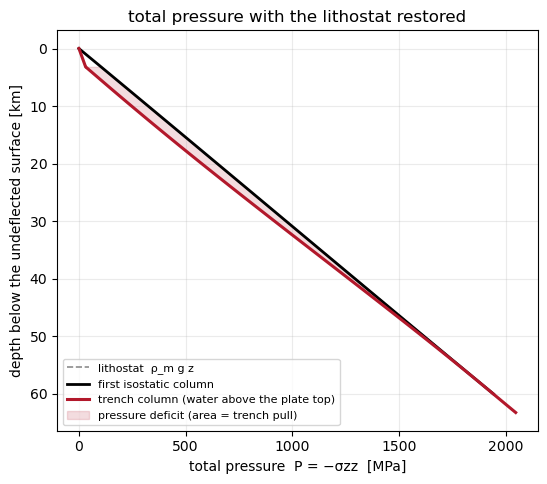

pressure at the trench plate top 31.11 MPa vs hydrostatic water ρ_w g z_top = 31.21 MPa;  area of the deficit = 2.539 TN/m


In [5]:
zt, zi = Lt["z"], Li["z"]; ztop = zt[0]                       # depth of this column's plate top
wT = w.max()                                                  # trench deflection as the paper defines it (topography maximum)
P_trench = RHO_M * G * zt - Lt["szz"]; P_iso = RHO_M * G * zi - Li["szz"]
zw = np.linspace(0, ztop, 20)
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.plot(RHO_M * G * zt / 1e6, zt / 1e3, color="0.55", lw=1.2, ls="--", label="lithostat  ρ_m g z")
ax.plot(P_iso / 1e6, zi / 1e3, color="k", lw=2.0, label="first isostatic column")
ax.plot(np.r_[RHO_W * G * zw, P_trench] / 1e6, np.r_[zw, zt] / 1e3, color="#b2182b", lw=2.2, label="trench column (water above the plate top)")
ax.fill_betweenx(zt / 1e3, P_trench / 1e6, RHO_M * G * zt / 1e6, color="#b2182b", alpha=0.15, label="pressure deficit (area = trench pull)")
ax.invert_yaxis(); ax.set_xlabel("total pressure  P = −σzz  [MPa]"); ax.set_ylabel("depth below the undeflected surface [km]")
ax.set_title("total pressure with the lithostat restored"); ax.legend(fontsize=8, loc="lower left"); ax.grid(alpha=0.25); plt.show()
print(f"pressure at the trench plate top {P_trench[0]/1e6:.2f} MPa vs hydrostatic water ρ_w g z_top = {RHO_W*G*ztop/1e6:.2f} MPa;  "
      f"area of the deficit = {np.trapz(RHO_M*G*zt - P_trench, zt)/1e12:.3f} TN/m")

## 4. The trench pull and the equilibrium identity
On each column integrate the vertical normal stress, Σzz = ∫σzz dz, and the normal-stress difference, N_D = ∫(σxx − σzz) dz.
Then ΔGPE\* = −[Σzz(x_I) − Σzz(x_T)] and ΔN_D = N_D(x_I) − N_D(x_T). Static equilibrium requires them to be equal.

ΔGPE* = 2.542 TN/m;  ΔN_D = 2.543 TN/m;  residual |ΔN_D − ΔGPE*|/|ΔGPE*| = 0.019 %
trench_pull(m) does the same: ΔGPE* = 2.542, ΔN_D = 2.543 TN/m, x_I = 182 km


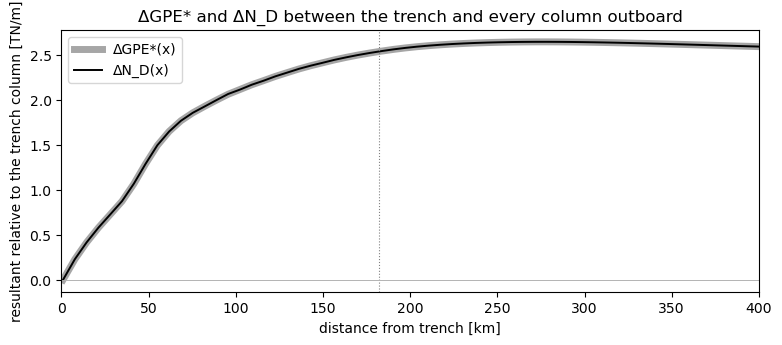

In [6]:
SzzT, NdT = m.deformed_resultants(xt); SzzI, NdI = m.deformed_resultants(xI)   # [N/m]
dGPE = -(SzzI - SzzT); dND = NdI - NdT
print(f"ΔGPE* = {dGPE/1e12:.3f} TN/m;  ΔN_D = {dND/1e12:.3f} TN/m;  residual |ΔN_D − ΔGPE*|/|ΔGPE*| = {abs(dGPE - dND)/abs(dGPE)*100:.3f} %")
g1, n1, x1 = trench_pull(m); print(f"trench_pull(m) does the same: ΔGPE* = {g1/1e12:.3f}, ΔN_D = {n1/1e12:.3f} TN/m, x_I = {x1:.0f} km")
xs = np.linspace(xt, 400, 60)
dG_x = np.array([-(m.deformed_resultants(x)[0] - SzzT) for x in xs]) / 1e12
dN_x = np.array([ (m.deformed_resultants(x)[1] - NdT)  for x in xs]) / 1e12
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(xs, dG_x, color="0.65", lw=5, label="ΔGPE*(x)"); ax.plot(xs, dN_x, color="k", lw=1.4, label="ΔN_D(x)")
ax.axvline(xI, color="0.5", lw=0.8, ls=":"); ax.axhline(0, color="0.7", lw=0.7); ax.set_xlim(0, 400)
ax.set_xlabel("distance from trench [km]"); ax.set_ylabel("resultant relative to the trench column [TN/m]")
ax.set_title("ΔGPE* and ΔN_D between the trench and every column outboard"); ax.legend(); plt.show()

## 5. The equivalent density ρ̂ and the effective arm
The pull is carried inside the plate by the horizontal gradient of the vertical shear stress. Written as a density,
ρ̂ = τzx,x / g, the trench column is a mass dipole: a water-for-rock deficit at the surface balanced by ρ̂ inside the plate.
Below, ρ̂ through the plate on the three columns, measured from each column's own plate top (so the shapes can be compared).

Two numbers, kept apart:
- the **effective arm**, the pull divided by the surface pressure deficit, ΔGPE\* / (Δρ g w_T). A force divided by a
  pressure; no curve involved. **This is the arm the paper reports.** It is drawn on the trench curve.
- the **centre of mass of each ρ̂ curve** (one circle per column). It shows where the support sits. There is no circle on the
  isostatic column: its net area is zero there (dV/dx = 0), so the centre of mass is undefined — the same rule as in the paper's figures.

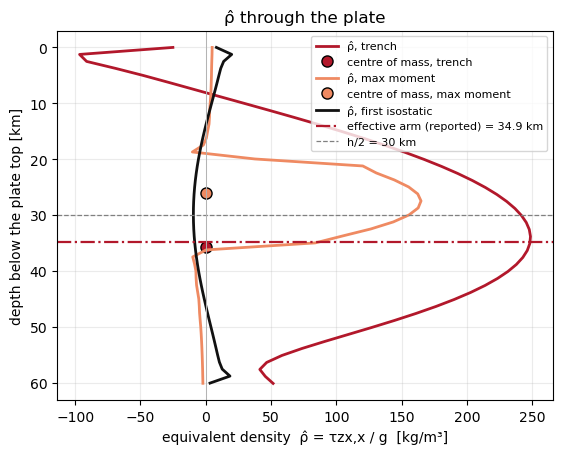

effective arm ΔGPE*/(Δρ g w_T) = 34.9 km  (h/2 = 30 km);  centre of mass of ρ̂ at the trench = 35.6 km


In [7]:
arm = dGPE / (DRHO_G * wT)                                            # effective arm [m]
fig, ax = plt.subplots(figsize=(6.4, 4.8))
for x, c, lab in [(xt, "#b2182b", "trench"), (xM, "#ef8a62", "max moment"), (xI, "#111111", "first isostatic")]:
    Lx, tau = deformed_shear_gradient(m, x); z = Lx["z"]; d = (z - z[0]) / 1e3      # τzx,x on the deformed column; depth below its plate top
    ax.plot(tau / G, d, color=c, lw=2, label=f"ρ̂, {lab}")
    net = np.trapz(tau, z)
    if abs(net) > 0.2 * np.trapz(np.abs(tau), z):                    # centre of mass only where the net area is well defined
        ax.plot(0, (np.trapz(z * tau, z) / net - z[0]) / 1e3, "o", color=c, ms=8, mec="k", label=f"centre of mass, {lab}")
ax.axhline(arm / 1e3, color="#b2182b", lw=1.6, ls="-.", label=f"effective arm (reported) = {arm/1e3:.1f} km")
ax.axhline(m.H / 2e3, color="0.5", lw=0.9, ls="--", label=f"h/2 = {m.H/2e3:.0f} km"); ax.axvline(0, color="0.7", lw=0.7)
ax.invert_yaxis(); ax.set_xlabel("equivalent density  ρ̂ = τzx,x / g  [kg/m³]"); ax.set_ylabel("depth below the plate top [km]")
ax.set_title("ρ̂ through the plate"); ax.legend(fontsize=8); ax.grid(alpha=0.25); plt.show()
Lx, tau = deformed_shear_gradient(m, xt); z = Lx["z"]
print(f"effective arm ΔGPE*/(Δρ g w_T) = {arm/1e3:.1f} km  (h/2 = {m.H/2e3:.0f} km);  centre of mass of ρ̂ at the trench = {(np.trapz(z*tau, z)/np.trapz(tau, z) - z[0])/1e3:.1f} km")

## 6. The pull reconstructed from ρ̂
With no body force, ∂σzz/∂z = −τzx,x and σzz = 0 at the base, so integrating by parts, Σzz on a column equals the first
moment of τzx,x about that column's plate top: Σzz = ∫ (z − z_top) τzx,x dz. The pull is therefore the dipole moment of ρ̂
(times g) with the arm measured from the plate top — the reconstruction of Fig. 5. Below, the direct Σzz and the
reconstruction on columns from the trench outboard. They agree to ~0.1 % once a few km inboard; at the trench column itself
the FE gradient carries the loaded-edge artefact (several %), which is why Fig. 5 references its profile 5 km inboard
(the SI's loaded-edge section). Far outboard the relative error grows only because Σzz itself becomes small.

In [8]:
print(f"{'column x [km]':>14s} {'Σzz direct':>12s} {'first moment of ρ̂g':>19s} {'diff':>7s}")
for x in [xt, xt + 2, xt + 5, xt + 10, 20, 40, 60, 90]:
    Szz_x, _ = m.deformed_resultants(x); Lx, tau = deformed_shear_gradient(m, x); z = Lx["z"]
    recon = np.trapz((z - z[0]) * tau, z)                            # Σzz from ρ̂: first moment about this column's plate top
    print(f"{x:14.1f} {Szz_x/1e12:12.3f} {recon/1e12:19.3f} {100*(recon-Szz_x)/Szz_x:6.1f} %")
approx = DRHO_G * wT * m.H / 2                                        # the paper's mid-plate shorthand: surface deficit × h/2
print(f"\nfor comparison, the mid-plate shorthand Δρ g w_T · h/2 = {approx/1e12:.3f} TN/m vs the direct ΔGPE* = {dGPE/1e12:.3f} TN/m  ({100*(approx-dGPE)/dGPE:+.1f} %)")

 column x [km]   Σzz direct first moment of ρ̂g    diff
           0.9        2.539               2.699    6.3 %
           2.9        2.466               2.499    1.3 %
           5.9        2.366               2.365   -0.0 %
          10.9        2.217               2.215   -0.1 %
          20.0        1.987               1.987    0.0 %
          40.0        1.520               1.546    1.7 %
          60.0        0.922               0.935    1.4 %
          90.0        0.526               0.512   -2.5 %

for comparison, the mid-plate shorthand Δρ g w_T · h/2 = 2.188 TN/m vs the direct ΔGPE* = 2.542 TN/m  (-13.9 %)


## 7. The corrected density ρ\*
The paper's construct: add the equivalent density to the true density, ρ\* = ρ + ρ̂. With that correction, every column —
isostatic or not — carries the same integrated mass down to the plate base: the trench column's water deficit is made up by ρ̂
inside the plate (Fig. 2(a), "equal corrected mass"). Left: ρ\* − ρ_m on the three columns (water above the plate top, ρ̂ inside).
Right: the cumulative average density from the surface, converging to the same value for every column.

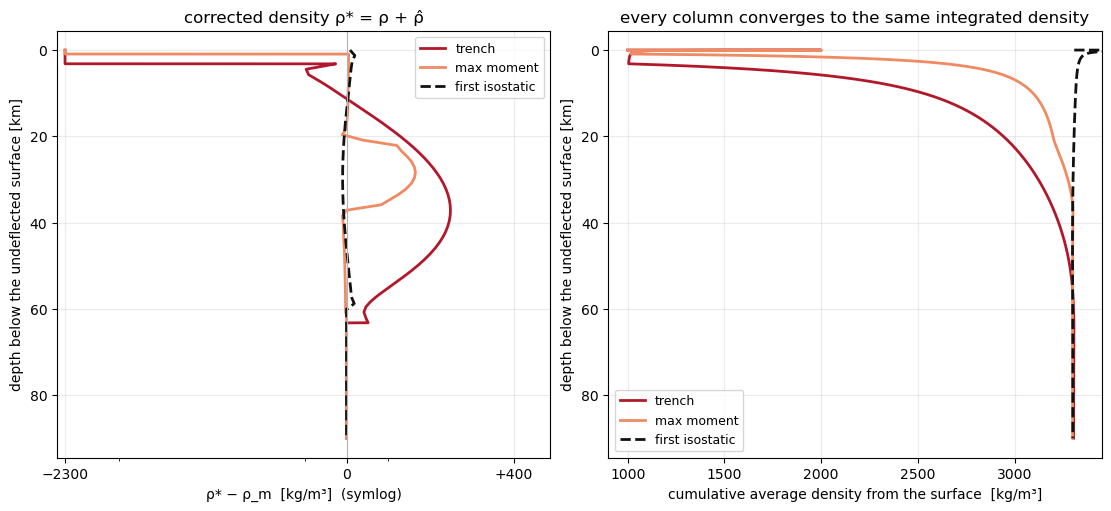

In [9]:
from matplotlib.ticker import FixedLocator, FixedFormatter
ZG = np.linspace(0, 90e3, 6000); DZ = ZG[1] - ZG[0]
def corrected(x):
    L, tau = deformed_shear_gradient(m, x); z = L["z"]; top, base = z[0], z[-1]
    r = np.full_like(ZG, RHO_M); r[ZG < top] = RHO_W                       # water above the deflected top
    ip = (ZG >= top) & (ZG <= base); r[ip] = RHO_M + np.interp(ZG[ip], z, tau / G)   # plate: ρ_m + ρ̂
    return r
cols = [(xt, "#b2182b", "trench"), (xM, "#ef8a62", "max moment"), (xI, "#111111", "first isostatic")]
fig, ax = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for x, c, lab in cols:
    r = corrected(x); ls = "--" if lab == "first isostatic" else "-"
    ax[0].plot(r - RHO_M, ZG / 1e3, color=c, lw=2, ls=ls, label=lab)
    ax[1].plot(np.cumsum(r) * DZ / np.maximum(ZG, DZ), ZG / 1e3, color=c, lw=2, ls=ls, label=lab)
ax[0].set_xscale("symlog", linthresh=400.0); ax[0].xaxis.set_major_locator(FixedLocator([-2300, 0, 400])); ax[0].xaxis.set_major_formatter(FixedFormatter(["−2300", "0", "+400"]))
ax[0].axvline(0, color="0.7", lw=0.8); ax[0].set_xlim(-2600, 700); ax[0].set_xlabel("ρ* − ρ_m  [kg/m³]  (symlog)"); ax[0].set_title("corrected density ρ* = ρ + ρ̂")
ax[1].set_xlim(900, 3450); ax[1].set_xlabel("cumulative average density from the surface  [kg/m³]"); ax[1].set_title("every column converges to the same integrated density")
for a in ax: a.invert_yaxis(); a.set_ylabel("depth below the undeflected surface [km]"); a.grid(alpha=0.25); a.legend(fontsize=9)
plt.show()

## 8. The same numbers for every model
All suites in `data/`, through the same steps as above (`summarize` is those steps). Then the paper's central empirical point
(Fig. 4): plotted against the trench deflection, the pull from the load sweep, the background-stress sweep, the four strength
models and the four thicknesses falls close to one line, above the mid-plate shorthand Δρ g w · h/2.

In [ ]:
def summarize(model_dir):
    mm = Model(model_dir); x_t = trench_ref_km(mm); x_i = reference_lines(mm)["isostatic"]
    S_t, N_t = mm.deformed_resultants(x_t); S_i, N_i = mm.deformed_resultants(x_i)
    dG = -(S_i - S_t); w_t = mm.topography().max()
    return dict(model=model_dir.split("/")[-1], h_km=mm.H/1e3, w_T_m=w_t, dGPE_TNm=dG/1e12, identity_pct=abs(dG - (N_i - N_t))/abs(dG)*100, arm_km=dG/(DRHO_G*w_t)/1e3)
SUITES = [("Suite 1 strength",   sorted(glob.glob("data/suite1_strength/*/")),   "^", "#2ca02c"),
          ("Suite 2 load",       sorted(glob.glob("data/suite2_load/*/")),       "s", "#1f77b4"),
          ("Suite 3 background", sorted(glob.glob("data/suite3_background/*/")), "D", "#d62728"),
          ("Suite 4 thickness",  sorted(glob.glob("data/suite4_thickness/*/")),  "v", "#9467bd"),
          ("App. B E-sweep",     sorted(glob.glob("data/appendixB_esweep/*/")),  "x", "0.5")]
print(f"{'suite':20s} {'model':32s} {'h':>4s} {'w_T [m]':>8s} {'ΔGPE* [TN/m]':>13s} {'identity %':>11s} {'arm [km]':>9s}")
rows = {}
for suite, dirs, mk, c in SUITES:
    rows[suite] = [summarize(d.rstrip("/")) for d in dirs]
    for r in rows[suite]: print(f"{suite:20s} {r['model']:32s} {r['h_km']:4.0f} {r['w_T_m']:8.0f} {r['dGPE_TNm']:13.3f} {r['identity_pct']:11.3f} {r['arm_km']:9.1f}")
fig, ax = plt.subplots(figsize=(7, 4.6))
for suite, dirs, mk, c in SUITES[:4]:
    ax.scatter([r["w_T_m"]/1e3 for r in rows[suite]], [r["dGPE_TNm"] for r in rows[suite]], marker=mk, s=55, color=c, ec="k", lw=0.5, label=suite, zorder=3)
wl = np.array([0, 4.2]); ax.plot(wl, DRHO_G * 30e3 * wl * 1e3 / 1e12, "k--", lw=1.2, label="Δρ g w · h/2  (h = 60 km)")
ax.set_xlabel("trench deflection w_T [km]"); ax.set_ylabel("trench pull ΔGPE* [TN/m]"); ax.set_title("pull vs deflection, all suites"); ax.legend(fontsize=8); ax.grid(alpha=0.25); plt.show()

## 9. The paper's figures from their scripts
Every manuscript figure has a script in `figures/` (`REPRODUCE.md` lists them). The main-text scripts are importable, so a
figure can be drawn here for any model; the single-shot SI benchmark scripts are simply run and their output displayed.

In [ ]:
import render_hero                                                     # Figure 3's script: the same layout for any model directory
fig = render_hero.build("data/suite1_strength/dd_vm_asym_60km_V4", save=False); plt.show()

In [ ]:
import render_gpe_compare as gc                                        # Figure 5's script: its plotting helper draws into any axes
mm, x, dgpe, pdsea, pdtop, approx_x = gc.profile(MODEL)
fig, ax = plt.subplots(figsize=(7, 4)); gc._plot_pull(ax, x, dgpe, pdtop, approx_x, legend=True)
ax.set_xlabel("distance from trench [km]"); ax.set_ylabel("ΔGPE* [TN/m]"); ax.set_title("Figure 5, reference model"); plt.show()

In [ ]:
subprocess.run([sys.executable, "figures/render_mp_benchmark.py"], check=True)   # an SI script: run it, then look at its output
from IPython.display import Image
Image("data/reference_figures/benchmark_mp.png", width=700)

## Where to go next
- `REPRODUCE.md` — every figure's exact command. `README.md` §4 — re-running the models with `model/paper_models.jl`.
- `analysis/gpe_analysis.py` — the extractor used above: `cauchy_fields`, `deformed_line`, `deformed_resultants`, `reference_lines`, `deformed_shear_gradient`.
- Thin-plate hero figures need a shorter plotting window: set `os.environ["HERO_WINDOW_KM"] = "200"` before importing `render_hero`.